# GPU-Accelerated Large-Scale Structure Formation MC

Uses CuPy for fast FFT and binning on RTX 3060 Ti.

GPU device: 1 available
Starting simulation: 451,000,000 defects on 256³ grid


Adding clustering: 100%|███████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 109615.46it/s]


Building density field on GPU...
Computing power spectrum on GPU...
Simulation completed in 15.7 seconds
Mean density: 26.8817


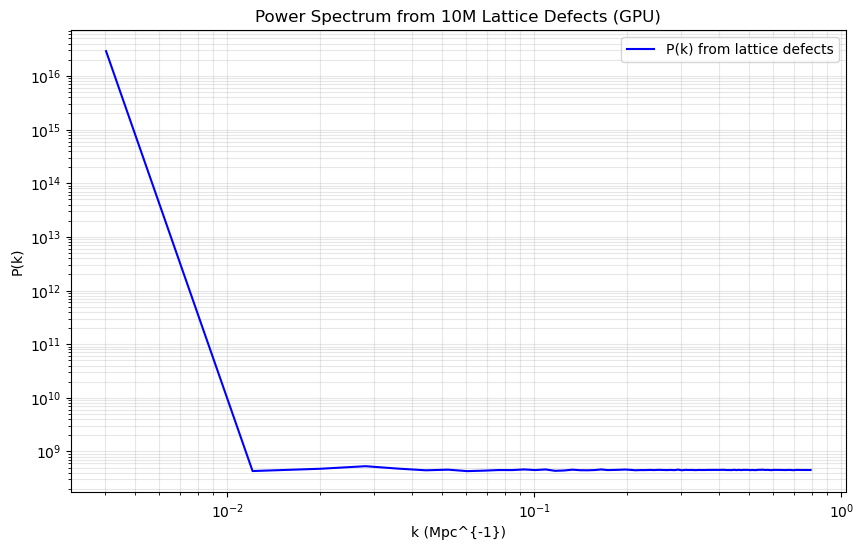

In [22]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# ====================== PARAMETERS ======================
N_defects =451_000_000      # 451 million defects
box_size = 1000.0           # Mpc
grid_size = 256             # 256³ grid
defect_size = 5.0           # Mpc
seed = 42

print(f"GPU device: {cp.cuda.runtime.getDeviceCount()} available")
print(f"Starting simulation: {N_defects:,} defects on {grid_size}³ grid")
start_time = time.time()

# ====================== GENERATE DEFECTS (CPU) ======================
np.random.seed(seed)
positions = np.random.uniform(0, box_size, (N_defects, 3))

# Clustering loop (CPU — can be parallelized later)
for i in tqdm(range(5000), desc="Adding clustering"):
    idx = np.random.randint(0, N_defects)
    positions[idx] += np.random.normal(0, defect_size, 3)
    positions[idx] = np.clip(positions[idx], 0, box_size)

# Move to GPU
positions_gpu = cp.asarray(positions)

# ====================== DENSITY FIELD (GPU) ======================
print("Building density field on GPU...")
density_gpu = cp.zeros((grid_size, grid_size, grid_size), dtype=cp.float32)
indices = (positions_gpu / box_size * grid_size).astype(cp.int32)
cp.add.at(density_gpu, (indices[:,0], indices[:,1], indices[:,2]), 1.0)

# ====================== POWER SPECTRUM (GPU FFT) ======================
print("Computing power spectrum on GPU...")
density_ft = cp.fft.fftn(density_gpu)
power = cp.abs(density_ft)**2

# Radial average (CPU for simplicity)
power_cpu = cp.asnumpy(power)
k = np.fft.fftfreq(grid_size, d=box_size/grid_size) * 2 * np.pi
k_mag = np.sqrt(k[:,None,None]**2 + k[None,:,None]**2 + k[None,None,:]**2)
k_bins = np.linspace(0, k.max(), 100)
p_k_1d = np.zeros(len(k_bins)-1)

for i in range(len(k_bins)-1):
    mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1])
    if mask.sum() > 0:
        p_k_1d[i] = power_cpu[mask].mean()

k_centers = (k_bins[:-1] + k_bins[1:]) / 2

print(f"Simulation completed in {time.time() - start_time:.1f} seconds")
print(f"Mean density: {cp.asnumpy(density_gpu.mean()):.4f}")

# Plot
plt.figure(figsize=(10,6))
plt.loglog(k_centers, p_k_1d, 'b-', label='P(k) from lattice defects')
plt.xlabel('k (Mpc^{-1})')
plt.ylabel('P(k)')
plt.title('Power Spectrum from 10M Lattice Defects (GPU)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.savefig('../figures/power-spectrum-10M-gpu.pdf')
plt.show()